# Iterative-Gaussianization warm start

Notebooks 01 and 02 trained Gaussianization / coupling flows from *random* initialisation. That works, but spends the first hundreds of epochs pulling the flow from a near-identity map towards the data.

**Iterative Gaussianization (RBIG — Laparra & Malo 2011)** is a non-gradient, greedy procedure that warm-starts the flow by walking block-by-block through the architecture and fitting each block's parameters directly:

1. **Rotation block** — fit PCA on the current state $Y$; push the eigenvectors into the rotation layer (for Householder this uses a QR decomposition to extract reflector vectors).
2. **Marginal block** — fit a per-dim mixture-of-Gaussians on the rotated data with scikit-learn's `GaussianMixture`, and assign $(\pi, \mu, \sigma)$ directly into the `MixtureCDFGaussianization` layer weights.
3. **Coupling block** — fit a per-b-dim GMM on the current $Y$; zero the conditioner's *final* Dense kernel and set its bias to the flattened GMM params. At initialisation the conditioner output is constant-in-$x_a$, so the coupling layer acts like a diagonal marginal with the fitted mixture. Gradient training then lets the conditioner learn to modulate on $x_a$.

Between blocks the current $Y$ is propagated forward through the newly-parameterised bijector, so the next block sees data that has already been partially Gaussianized. A classical result (Laparra & Malo 2011, Chen & Gopinath 2000) is that this drives $Y$ towards $\mathcal{N}(0, I)$ at a geometric rate — even with *no* gradient descent at all, the flow is already a decent density estimator after a handful of blocks.

The point of this notebook: a Keras flow initialised this way starts at a much lower NLL than random init and reaches its training optimum in a fraction of the epochs.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from keras import ops
from sklearn.datasets import make_moons

from gaussianization.gauss_keras import (
    base_nll_loss,
    initialize_flow_from_ig,
    make_coupling_flow,
    make_gaussianization_flow,
)

# --- global plot styling ------------------------------------------------------
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.2,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


def style_jointgrid(g, aspect="equal"):
    style_axes(g.ax_joint, aspect=aspect)
    style_axes(g.ax_marg_x, grid=False)
    style_axes(g.ax_marg_y, grid=False)
    for spine in ("top", "right"):
        g.ax_marg_x.spines[spine].set_visible(False)
        g.ax_marg_y.spines[spine].set_visible(False)


palette = sns.color_palette("deep")
COLOR_RANDOM = palette[3]
COLOR_IG = palette[2]

keras.utils.set_random_seed(0)
np.random.seed(0)

I0000 00:00:1776868596.826946  386554 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Dataset
Two moons, standardised. Same data as notebooks 01/02 so the comparison is apples-to-apples.

In [2]:
X_raw, _ = make_moons(n_samples=5000, noise=0.05, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = X.astype("float32")

## 2. Diagonal flow — random vs IG init

Build two identical diagonal flows, warm-start one of them from IG, and train both with the same optimiser and schedule.

In [3]:
def build_diagonal_flow():
    return make_gaussianization_flow(
        input_dim=2,
        num_blocks=8,
        num_reflectors=2,
        num_components=8,
        pca_init_data=X,
        mixture_init_data=X,
    )


keras.utils.set_random_seed(1)
flow_random = build_diagonal_flow()
_ = flow_random(ops.convert_to_tensor(X[:4]))

keras.utils.set_random_seed(1)
flow_ig = build_diagonal_flow()
_ = flow_ig(ops.convert_to_tensor(X[:4]))
initialize_flow_from_ig(flow_ig, X)

E0000 00:00:1776868601.498397  386554 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


array([[ 0.21370773,  0.68232536],
       [-1.675768  , -0.09274741],
       [ 0.5233947 ,  1.6713623 ],
       ...,
       [ 1.3039094 , -0.8307837 ],
       [ 0.17580122, -0.15649901],
       [ 0.17348166, -0.39425728]], shape=(5000, 2), dtype=float32)

### Before any training: what did IG init already buy us?

RBIG on its own produces a density estimate. Below we compare the mean log-likelihood (per sample) of the IG-initialised flow against the random-init flow, both *before* a single gradient step.

In [4]:
lp_random0 = float(np.mean(ops.convert_to_numpy(
    flow_random.log_prob(ops.convert_to_tensor(X))
)))
lp_ig0 = float(np.mean(ops.convert_to_numpy(
    flow_ig.log_prob(ops.convert_to_tensor(X))
)))
print(f"mean log-likelihood before training:")
print(f"  random init : {lp_random0:+.3f} nats/sample")
print(f"  IG init     : {lp_ig0:+.3f} nats/sample  (improvement: {lp_ig0 - lp_random0:+.3f})")

mean log-likelihood before training:
  random init : -881.520 nats/sample
  IG init     : -1.652 nats/sample  (improvement: +879.868)


### Pushforward at IG-init time

With no gradient training whatsoever, the pushforward of the IG-initialised flow should already be approximately $\mathcal{N}(0, I)$. Jointplots make this immediately visible — the IG scatter should look isotropic and the marginals should line up with the black $\mathcal{N}(0, 1)$ curves, while the random-init pushforward won't.

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


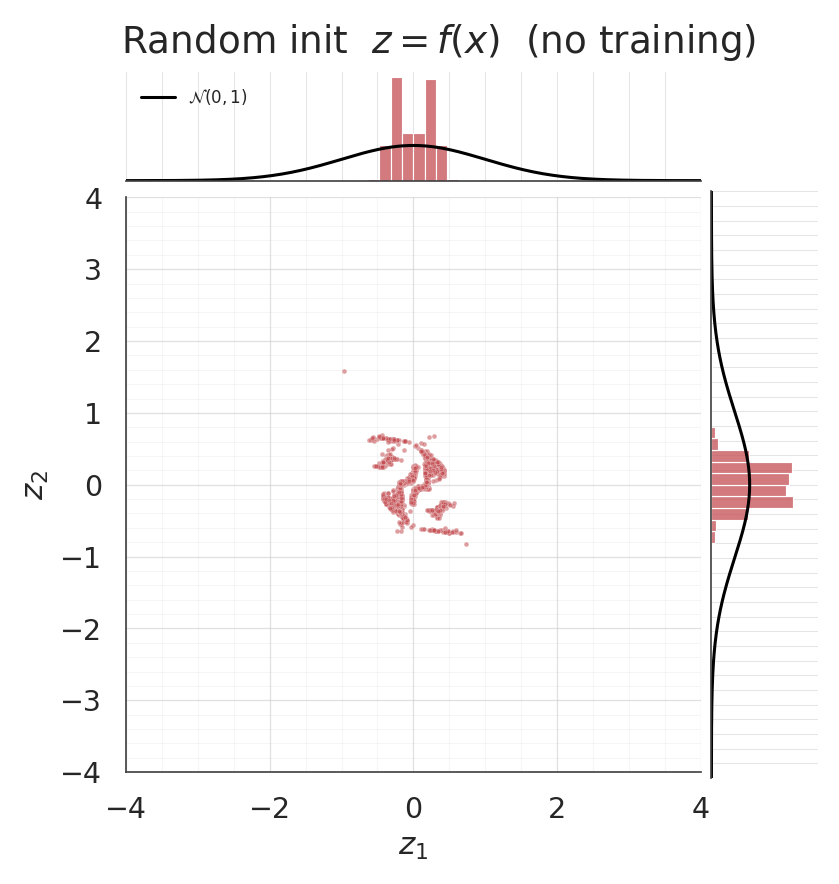

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


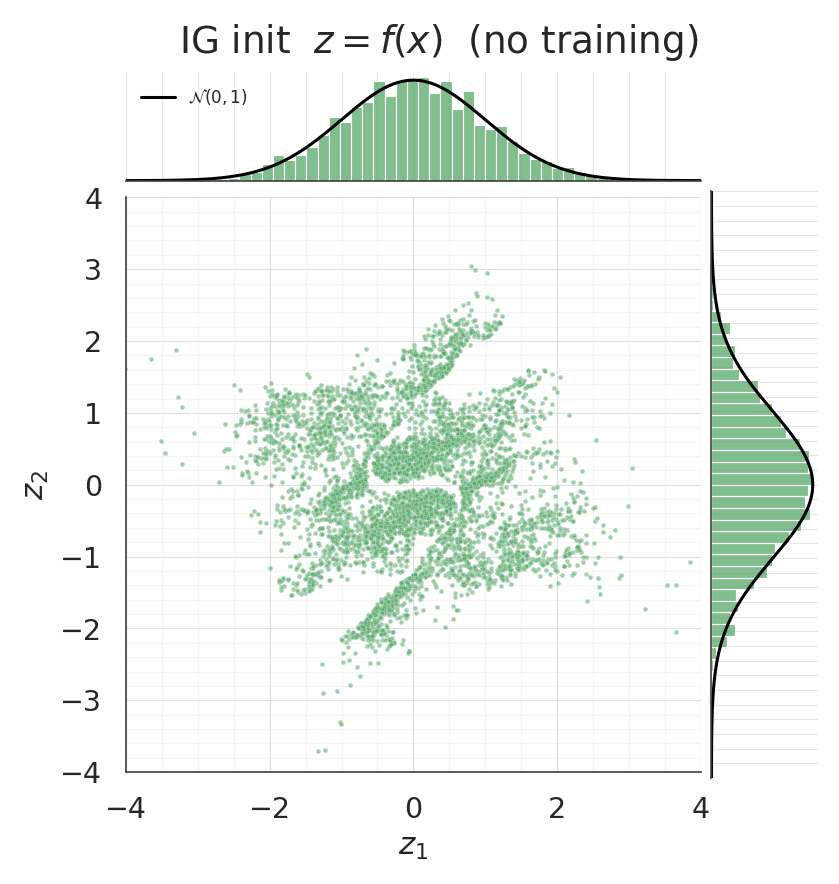

IG-init pushforward (pre-training)
  mean:    [+0.000, -0.000]   target = [0, 0]
  cov[0,0]:1.003    cov[1,1]:1.006    target = 1, 1
  cov[0,1]:+0.004                          target = 0


In [5]:
z_ig0 = ops.convert_to_numpy(flow_ig(ops.convert_to_tensor(X)))
z_rnd0 = ops.convert_to_numpy(flow_random(ops.convert_to_tensor(X)))

zz = np.linspace(-4, 4, 300)
phi = np.exp(-0.5 * zz**2) / np.sqrt(2 * np.pi)

for z_sample, title, col in [
    (z_rnd0, "Random init  $z = f(x)$  (no training)", COLOR_RANDOM),
    (z_ig0, "IG init  $z = f(x)$  (no training)", COLOR_IG),
]:
    g = sns.jointplot(
        x=z_sample[:, 0], y=z_sample[:, 1], kind="scatter", color=col,
        height=7.5, ratio=5, space=0.1,
        joint_kws={"s": 10, "alpha": 0.55},
        marginal_kws={
            "bins": 60, "color": col, "alpha": 0.75,
            "edgecolor": "white", "stat": "density",
        },
        xlim=(-4, 4), ylim=(-4, 4),
    )
    g.ax_marg_x.plot(zz, phi, color="black", linewidth=2.0, label="$\\mathcal{N}(0, 1)$")
    g.ax_marg_y.plot(phi, zz, color="black", linewidth=2.0)
    g.ax_marg_x.legend(loc="upper left", frameon=False, fontsize=11)
    g.set_axis_labels("$z_1$", "$z_2$")
    g.figure.suptitle(title, y=1.02)
    style_jointgrid(g)
    plt.show()

mean_ig0 = z_ig0.mean(axis=0)
cov_ig0 = np.cov(z_ig0, rowvar=False)
print("IG-init pushforward (pre-training)")
print(f"  mean:    [{mean_ig0[0]:+.3f}, {mean_ig0[1]:+.3f}]   target = [0, 0]")
print(f"  cov[0,0]:{cov_ig0[0, 0]:.3f}    cov[1,1]:{cov_ig0[1, 1]:.3f}    target = 1, 1")
print(f"  cov[0,1]:{cov_ig0[0, 1]:+.3f}                          target = 0")

### Training comparison

Both flows, same optimiser, same 150 epochs. The IG curve starts at (and finishes near) the random curve's *final* value — the zoomed panel on the right makes the small end-of-training gap legible.

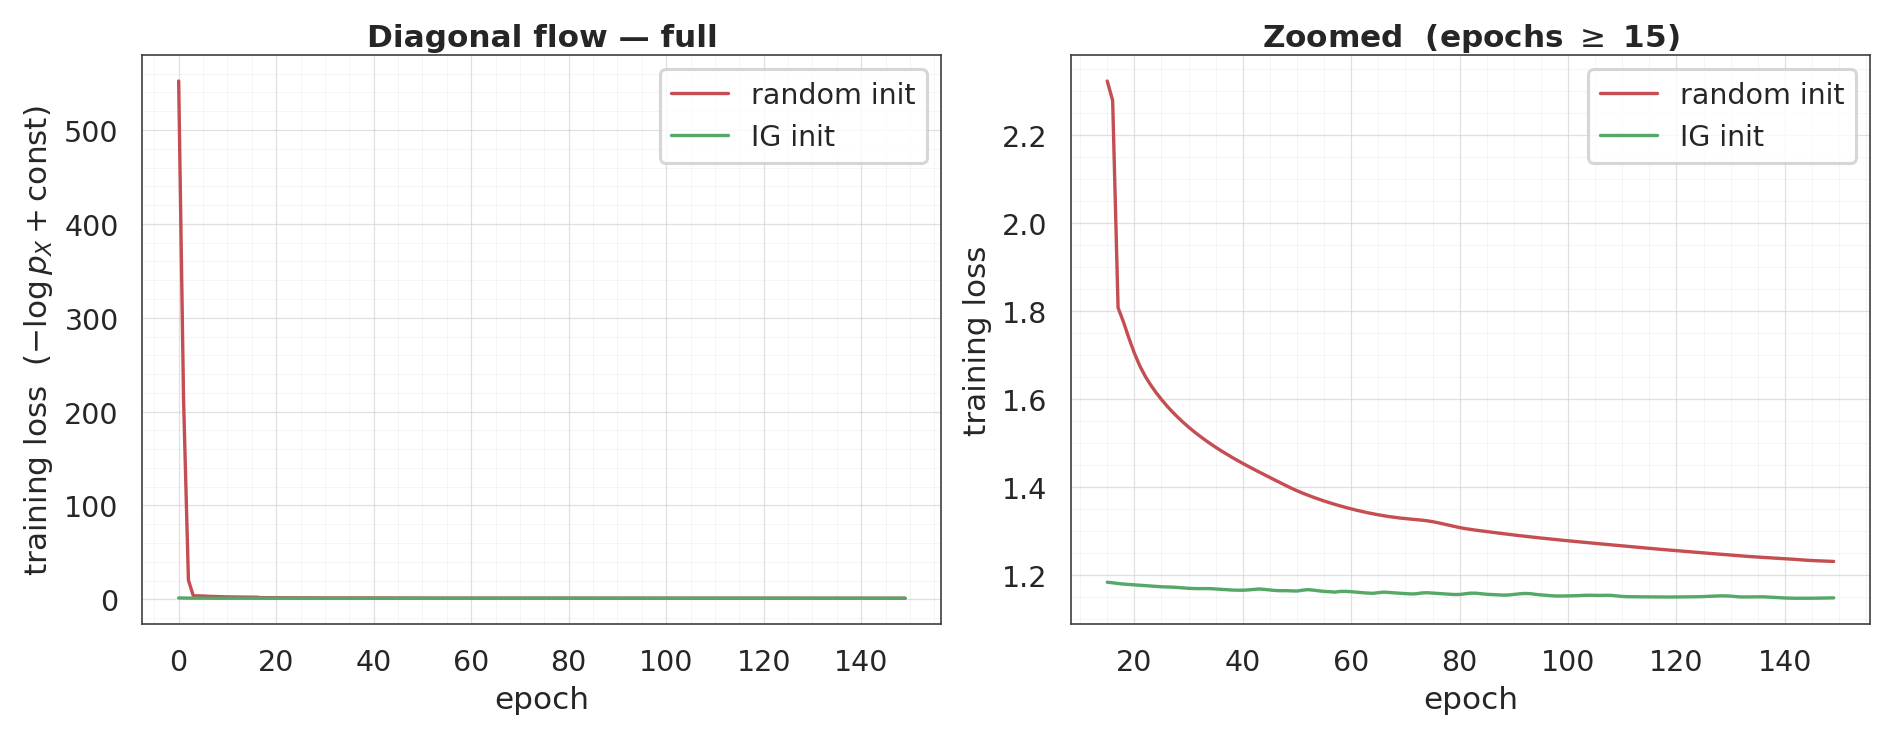

final loss:  random init = +1.232   IG init = +1.149


In [6]:
flow_random.compile(optimizer=keras.optimizers.Adam(5e-3), loss=base_nll_loss)
flow_ig.compile(optimizer=keras.optimizers.Adam(5e-3), loss=base_nll_loss)

hist_random = flow_random.fit(X, X, batch_size=512, epochs=150, verbose=0)
hist_ig = flow_ig.fit(X, X, batch_size=512, epochs=150, verbose=0)

rnd_curve = np.asarray(hist_random.history["loss"])
ig_curve = np.asarray(hist_ig.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

ax = axes[0]
ax.plot(rnd_curve, label="random init", color=COLOR_RANDOM, linewidth=2.2)
ax.plot(ig_curve, label="IG init", color=COLOR_IG, linewidth=2.2)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss  $(-\\log p_X + \\text{const})$")
ax.set_title("Diagonal flow — full")
ax.legend(frameon=True)
style_axes(ax)

ax = axes[1]
tail_start = 15
tail_rnd = rnd_curve[tail_start:]
tail_ig = ig_curve[tail_start:]
both = np.concatenate([tail_rnd, tail_ig])
span = both.max() - both.min()
ax.plot(range(tail_start, len(rnd_curve)), tail_rnd,
        label="random init", color=COLOR_RANDOM, linewidth=2.2)
ax.plot(range(tail_start, len(ig_curve)), tail_ig,
        label="IG init", color=COLOR_IG, linewidth=2.2)
ax.set_ylim(both.min() - 0.05 * span, both.max() + 0.05 * span)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title(f"Zoomed  (epochs $\\geq$ {tail_start})")
ax.legend(frameon=True)
style_axes(ax)

plt.show()
print(f"final loss:  random init = {rnd_curve[-1]:+.3f}   "
      f"IG init = {ig_curve[-1]:+.3f}")

### Density and samples after training

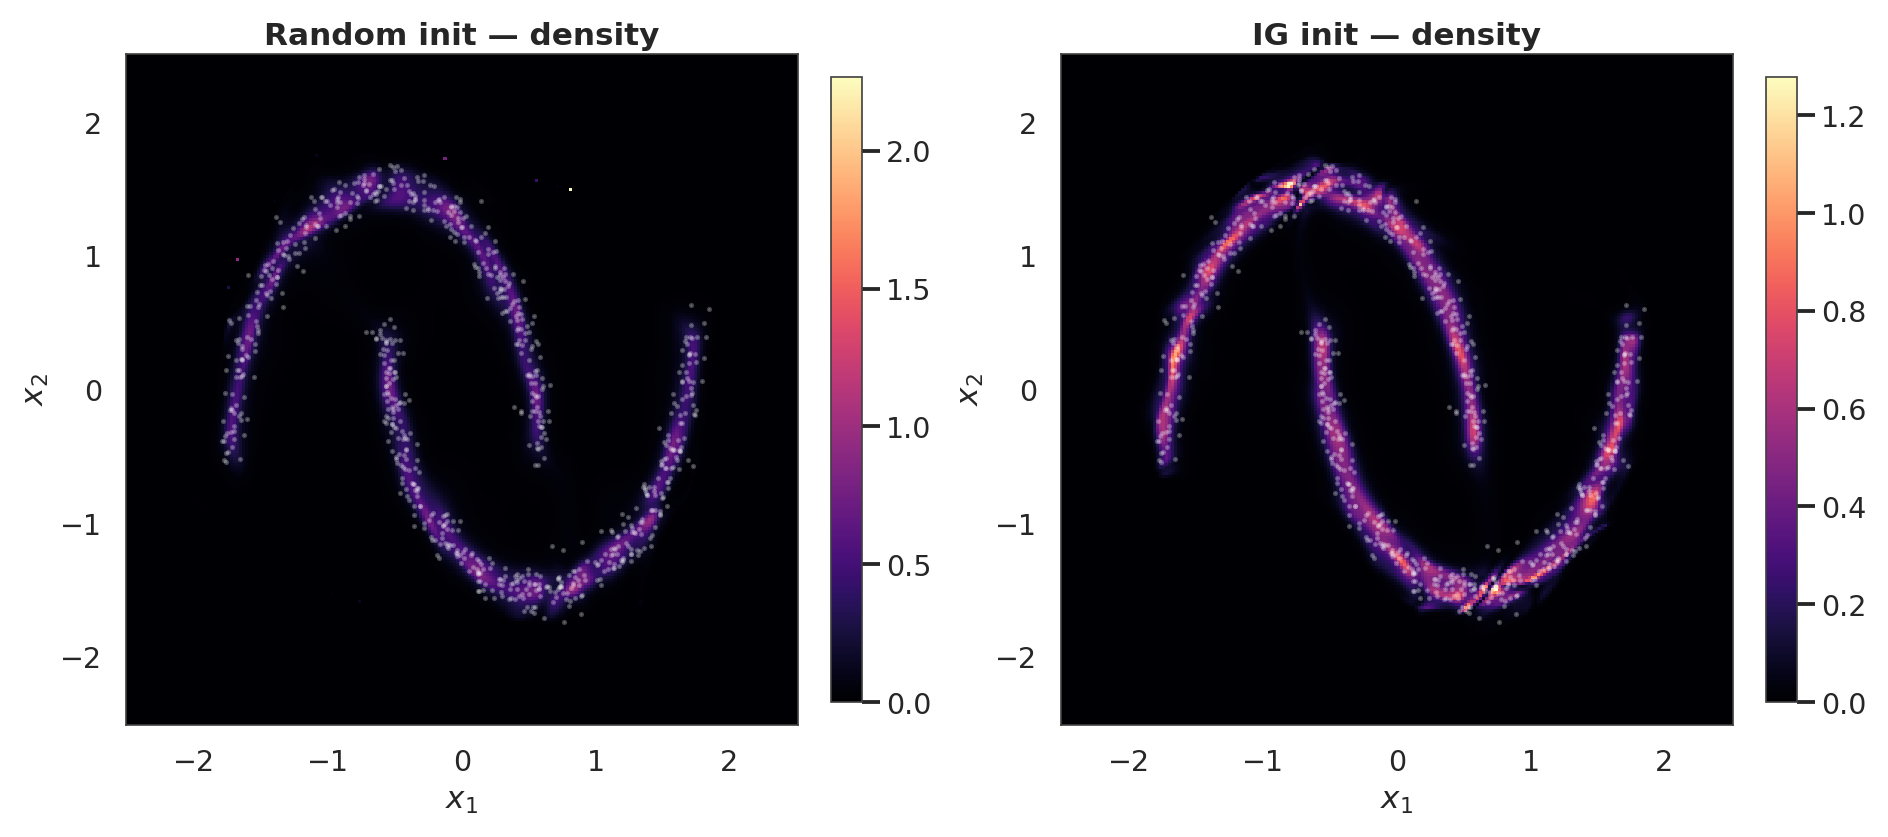

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


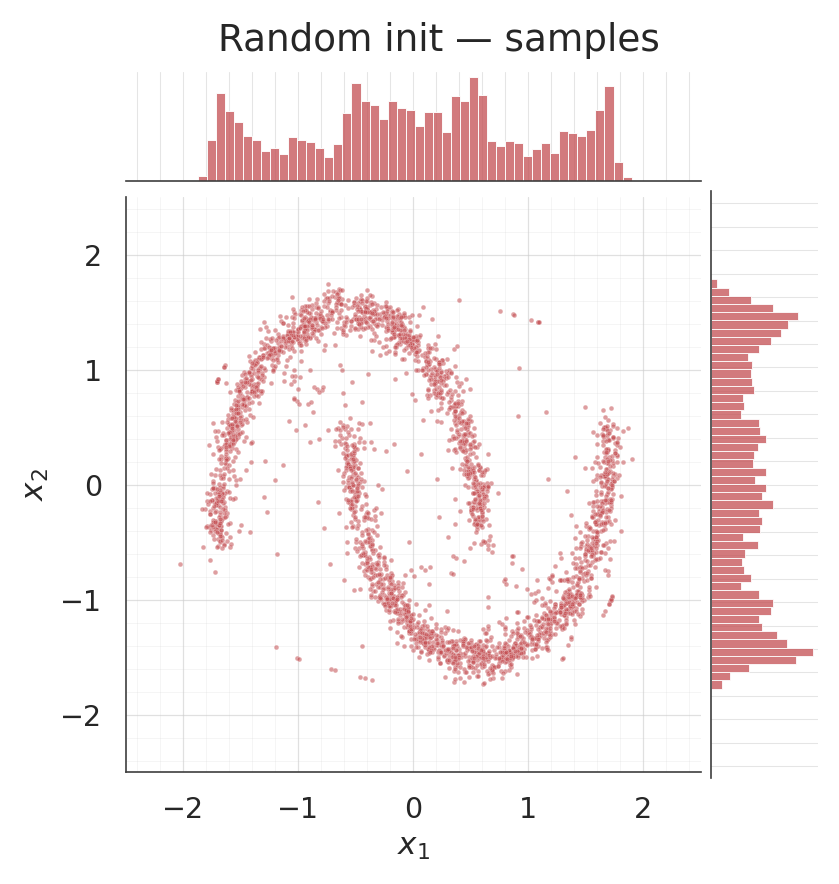

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


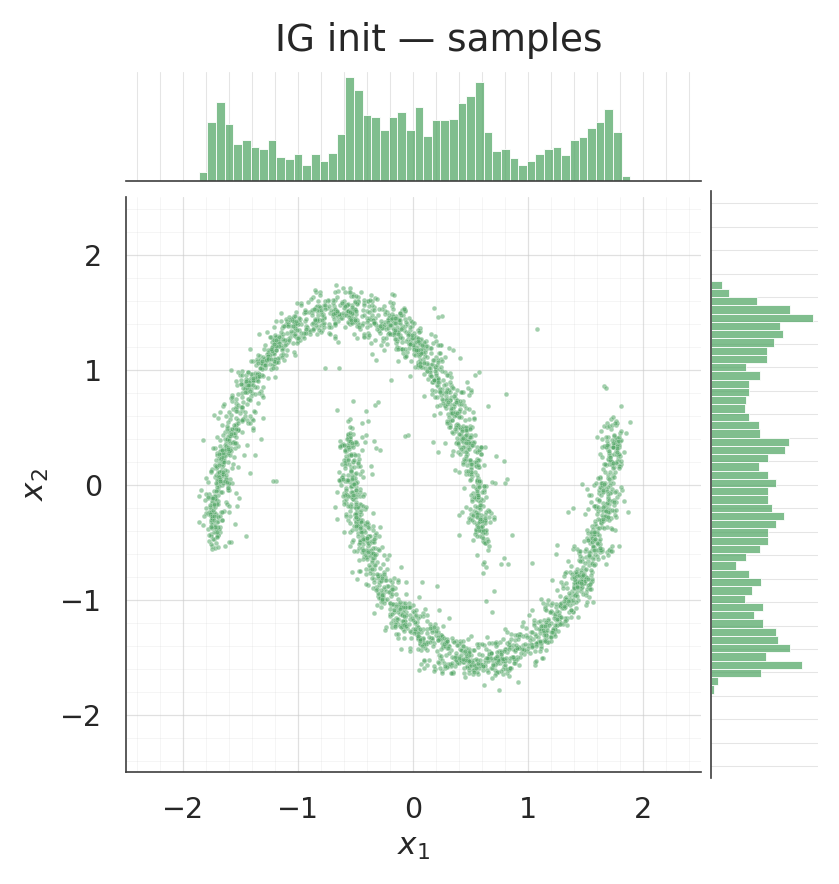

In [7]:
grid = 220
xs = np.linspace(-2.5, 2.5, grid).astype("float32")
ys = np.linspace(-2.5, 2.5, grid).astype("float32")
xx, yy = np.meshgrid(xs, ys)
pts = np.stack([xx.ravel(), yy.ravel()], axis=-1).astype("float32")

log_px_rnd = ops.convert_to_numpy(
    flow_random.log_prob(ops.convert_to_tensor(pts))
).reshape(grid, grid)
log_px_ig = ops.convert_to_numpy(
    flow_ig.log_prob(ops.convert_to_tensor(pts))
).reshape(grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, lp, title in zip(
    axes, [log_px_rnd, log_px_ig], ["Random init — density", "IG init — density"]
):
    pcm = ax.pcolormesh(xx, yy, np.exp(lp), cmap="magma", shading="auto")
    ax.scatter(X[:800, 0], X[:800, 1], s=2, alpha=0.25, color="white")
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    style_axes(ax, aspect="equal")
    fig.colorbar(pcm, ax=ax, shrink=0.85)
plt.show()

samples_rnd = ops.convert_to_numpy(flow_random.sample(num_samples=3000, seed=2))
samples_ig = ops.convert_to_numpy(flow_ig.sample(num_samples=3000, seed=2))

for s, title, col in [
    (samples_rnd, "Random init — samples", COLOR_RANDOM),
    (samples_ig, "IG init — samples", COLOR_IG),
]:
    g = sns.jointplot(
        x=s[:, 0], y=s[:, 1], kind="scatter", color=col,
        height=7.5, ratio=5, space=0.1,
        joint_kws={"s": 10, "alpha": 0.55},
        marginal_kws={"bins": 50, "color": col, "alpha": 0.75, "edgecolor": "white"},
        xlim=(-2.5, 2.5), ylim=(-2.5, 2.5),
    )
    g.set_axis_labels("$x_1$", "$x_2$")
    g.figure.suptitle(title, y=1.02)
    style_jointgrid(g)
    plt.show()

## 3. Coupling flow — random vs IG init

Same experiment with a coupling flow. IG init for coupling layers is weaker in isolation (the conditioner is *not* exercised at init — it emits a constant bias), but it still lets training skip the "the conditioner is effectively random, so the coupling transform is random" phase by handing it a sensible starting point where the conditioner behaves as a well-fit diagonal marginal.

In [8]:
def build_coupling_flow():
    return make_coupling_flow(
        input_dim=2,
        num_blocks=4,
        num_components=8,
        hidden=(64, 64),
    )


keras.utils.set_random_seed(3)
cpl_random = build_coupling_flow()
_ = cpl_random(ops.convert_to_tensor(X[:4]))

keras.utils.set_random_seed(3)
cpl_ig = build_coupling_flow()
_ = cpl_ig(ops.convert_to_tensor(X[:4]))
initialize_flow_from_ig(cpl_ig, X)

array([[ 0.33592415, -0.63961166],
       [-1.7532271 , -0.11788122],
       [ 0.52066326, -1.6266781 ],
       ...,
       [ 1.1722953 ,  0.8738398 ],
       [ 0.15655102,  0.20274866],
       [ 0.06255252,  0.3414428 ]], shape=(5000, 2), dtype=float32)

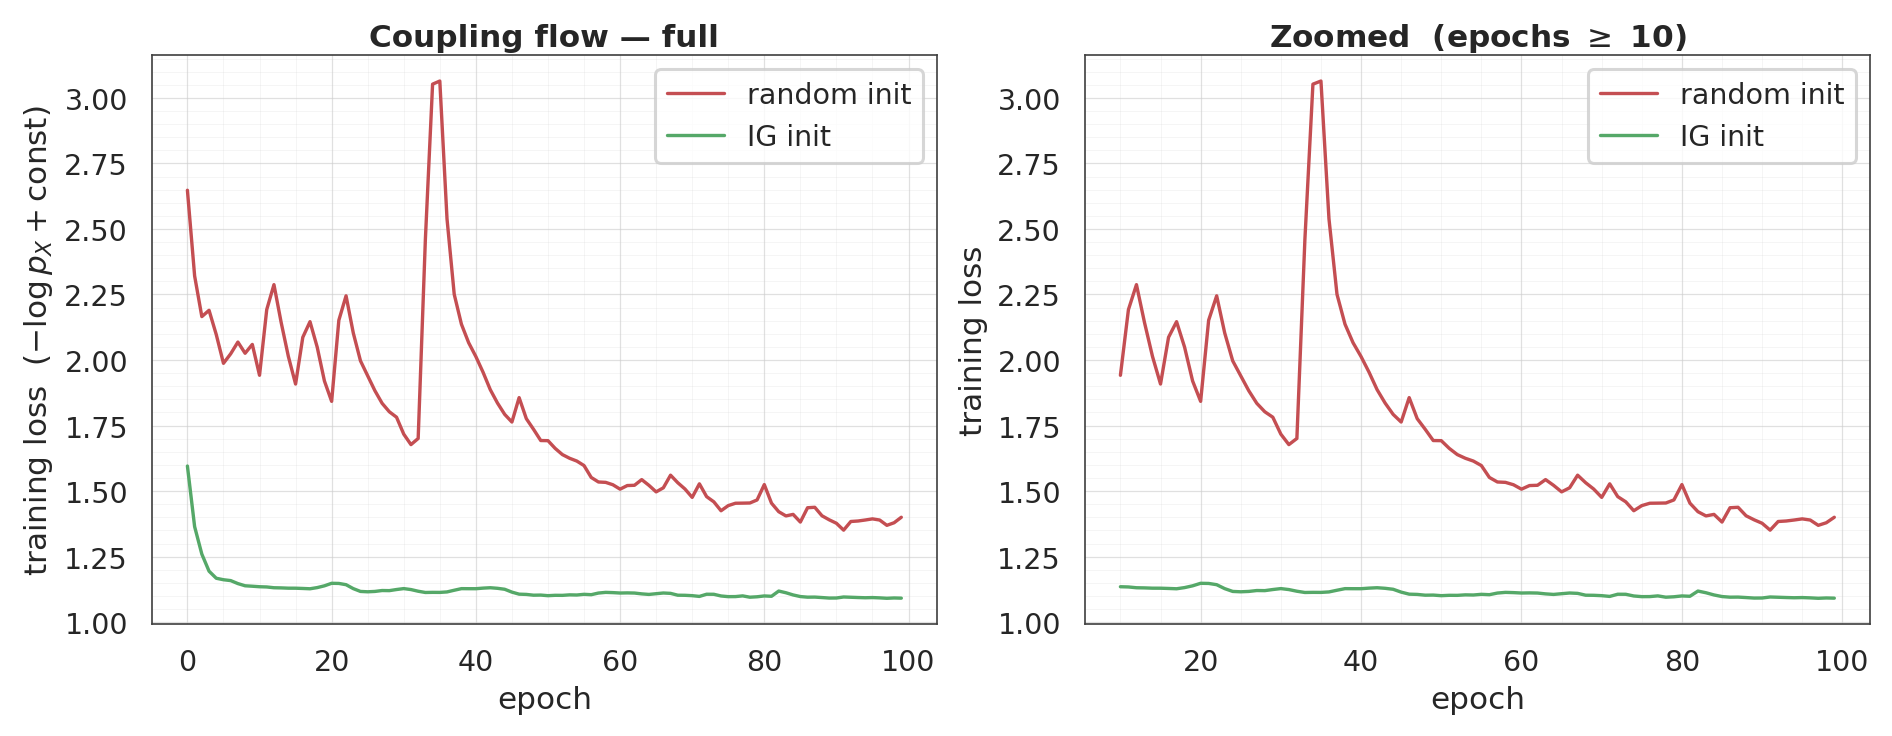

final loss:  random init = +1.400   IG init = +1.092


In [9]:
cpl_random.compile(optimizer=keras.optimizers.Adam(3e-3), loss=base_nll_loss)
cpl_ig.compile(optimizer=keras.optimizers.Adam(3e-3), loss=base_nll_loss)

hist_c_random = cpl_random.fit(X, X, batch_size=512, epochs=100, verbose=0)
hist_c_ig = cpl_ig.fit(X, X, batch_size=512, epochs=100, verbose=0)

crnd_curve = np.asarray(hist_c_random.history["loss"])
cig_curve = np.asarray(hist_c_ig.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

ax = axes[0]
ax.plot(crnd_curve, label="random init", color=COLOR_RANDOM, linewidth=2.2)
ax.plot(cig_curve, label="IG init", color=COLOR_IG, linewidth=2.2)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss  $(-\\log p_X + \\text{const})$")
ax.set_title("Coupling flow — full")
ax.legend(frameon=True)
style_axes(ax)

ax = axes[1]
tail_start = 10
tail_rnd = crnd_curve[tail_start:]
tail_ig = cig_curve[tail_start:]
both = np.concatenate([tail_rnd, tail_ig])
span = both.max() - both.min()
ax.plot(range(tail_start, len(crnd_curve)), tail_rnd,
        label="random init", color=COLOR_RANDOM, linewidth=2.2)
ax.plot(range(tail_start, len(cig_curve)), tail_ig,
        label="IG init", color=COLOR_IG, linewidth=2.2)
ax.set_ylim(both.min() - 0.05 * span, both.max() + 0.05 * span)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title(f"Zoomed  (epochs $\\geq$ {tail_start})")
ax.legend(frameon=True)
style_axes(ax)

plt.show()
print(f"final loss:  random init = {crnd_curve[-1]:+.3f}   "
      f"IG init = {cig_curve[-1]:+.3f}")

### Coupling density and samples after training

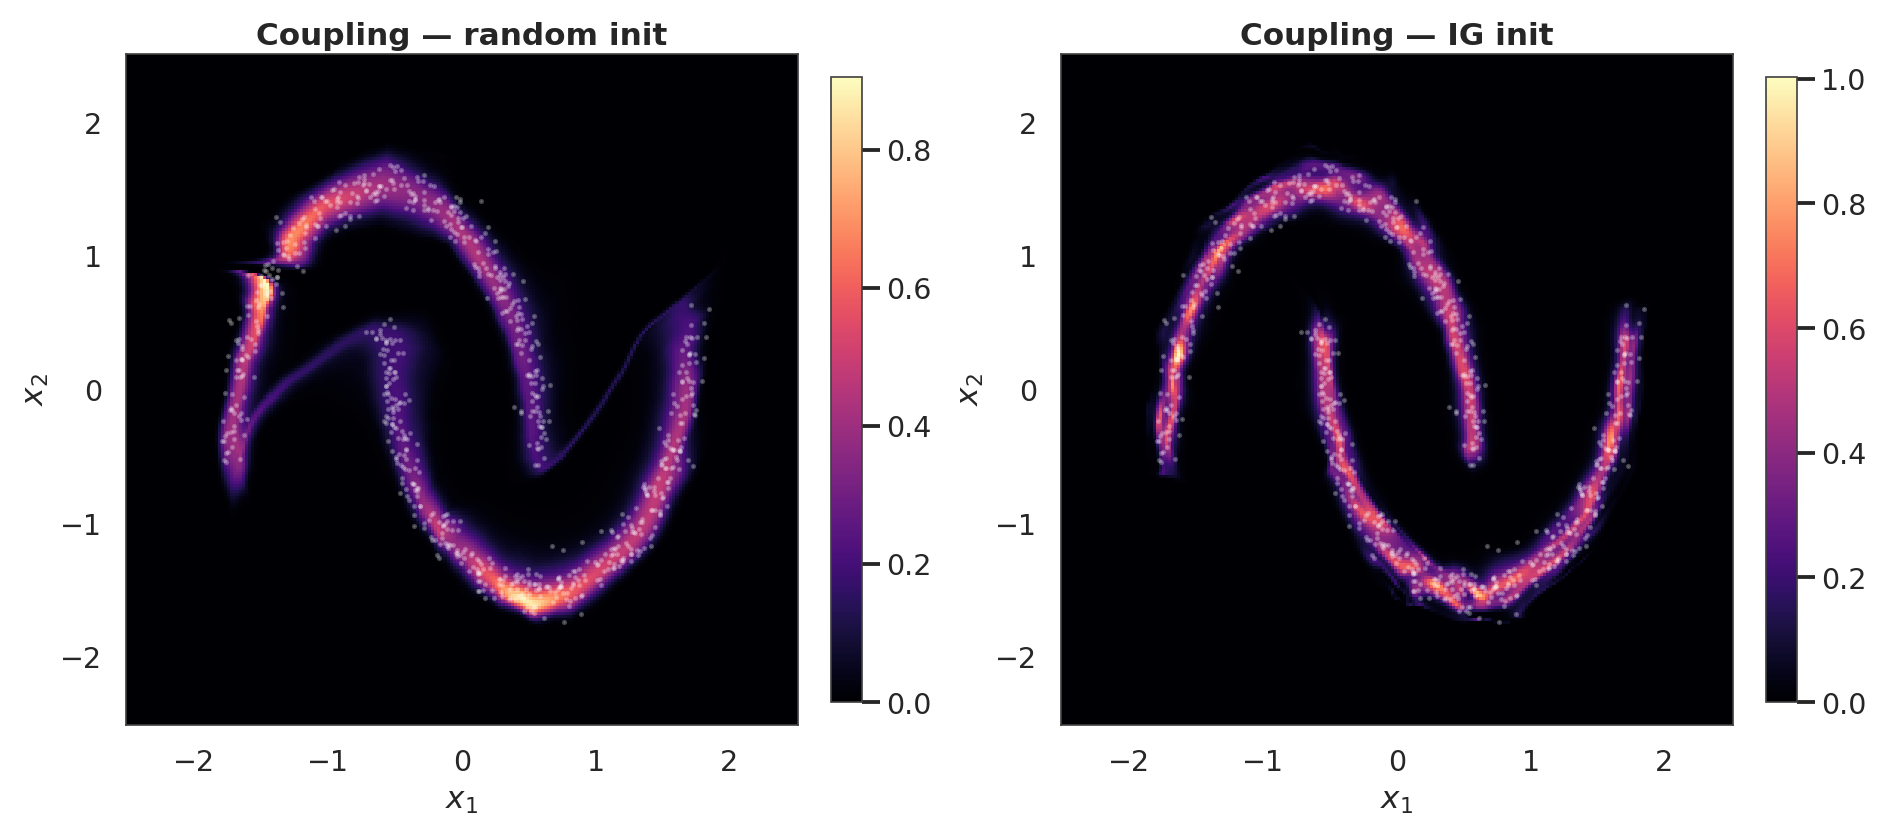

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


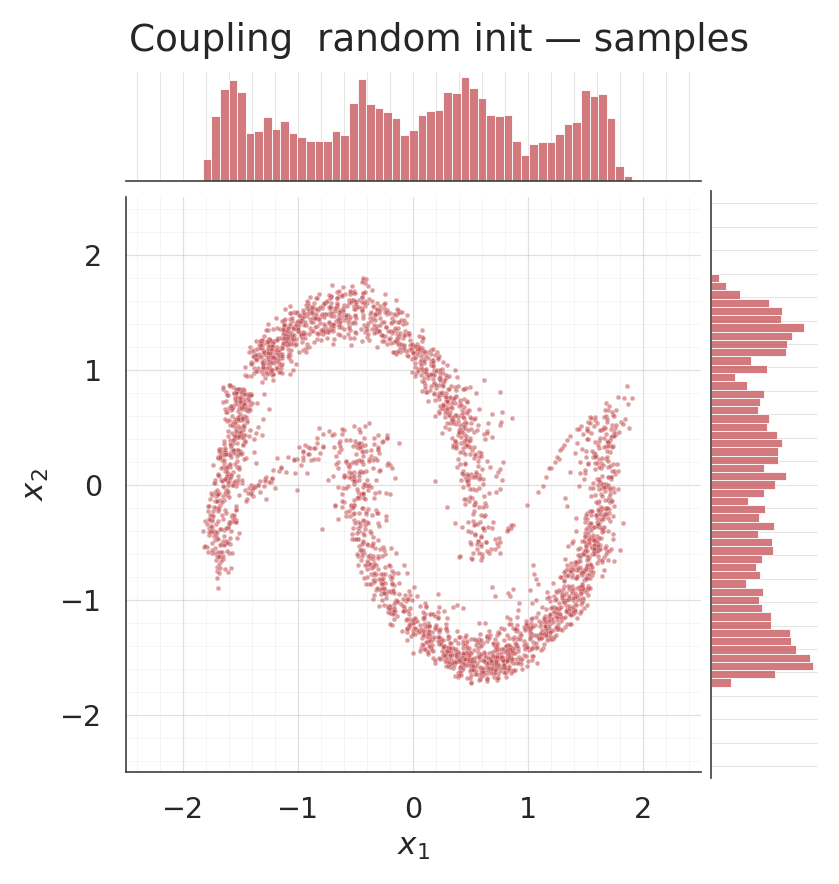

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


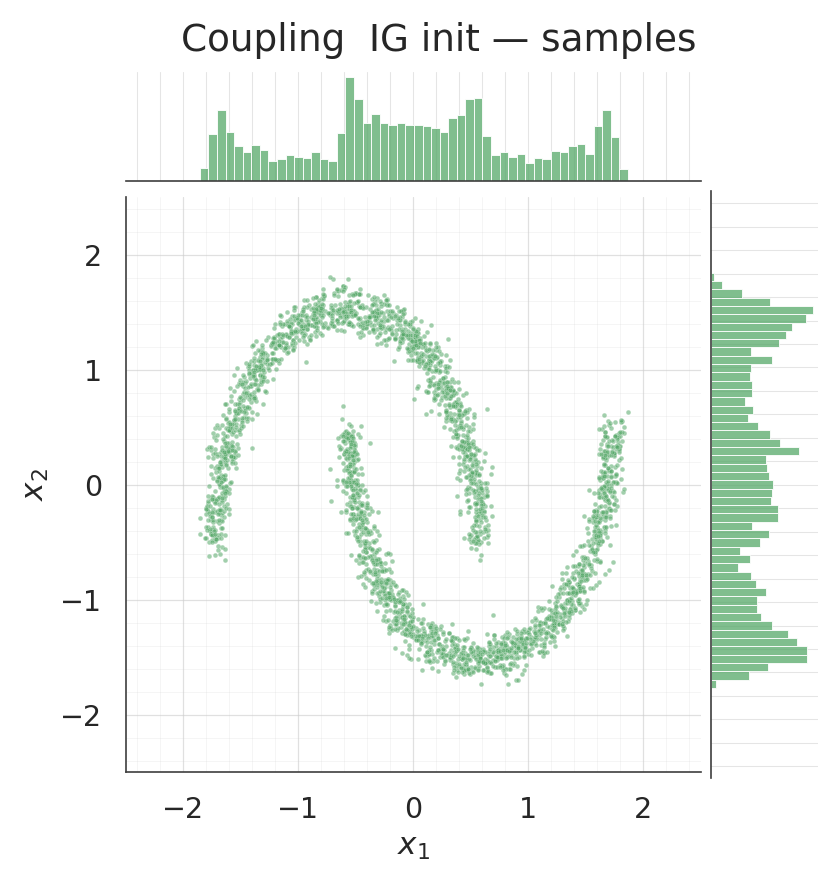

In [10]:
log_px_crnd = ops.convert_to_numpy(
    cpl_random.log_prob(ops.convert_to_tensor(pts))
).reshape(grid, grid)
log_px_cig = ops.convert_to_numpy(
    cpl_ig.log_prob(ops.convert_to_tensor(pts))
).reshape(grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, lp, title in zip(
    axes, [log_px_crnd, log_px_cig], ["Coupling — random init", "Coupling — IG init"]
):
    pcm = ax.pcolormesh(xx, yy, np.exp(lp), cmap="magma", shading="auto")
    ax.scatter(X[:800, 0], X[:800, 1], s=2, alpha=0.25, color="white")
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    style_axes(ax, aspect="equal")
    fig.colorbar(pcm, ax=ax, shrink=0.85)
plt.show()

csamples_rnd = ops.convert_to_numpy(cpl_random.sample(num_samples=3000, seed=4))
csamples_ig = ops.convert_to_numpy(cpl_ig.sample(num_samples=3000, seed=4))

for s, title, col in [
    (csamples_rnd, "Coupling  random init — samples", COLOR_RANDOM),
    (csamples_ig, "Coupling  IG init — samples", COLOR_IG),
]:
    g = sns.jointplot(
        x=s[:, 0], y=s[:, 1], kind="scatter", color=col,
        height=7.5, ratio=5, space=0.1,
        joint_kws={"s": 10, "alpha": 0.55},
        marginal_kws={"bins": 50, "color": col, "alpha": 0.75, "edgecolor": "white"},
        xlim=(-2.5, 2.5), ylim=(-2.5, 2.5),
    )
    g.set_axis_labels("$x_1$", "$x_2$")
    g.figure.suptitle(title, y=1.02)
    style_jointgrid(g)
    plt.show()

## 4. Verifying the zero-kernel contract

*Immediately* after `initialize_flow_from_ig` every `MixtureCDFCoupling`'s **final** Dense has a zero kernel (so the conditioner emits its bias for any input — the coupling layer behaves as a diagonal marginal). During gradient training those kernels become non-zero as the conditioner learns to modulate on $x_a$.

Below: build a fresh coupling flow, IG-init it, check the kernels **before** any training, then train briefly and check again.

In [11]:
from gaussianization.gauss_keras.bijectors import MixtureCDFCoupling


def max_final_kernel(flow):
    out = []
    for b in flow.bijector_layers:
        if isinstance(b, MixtureCDFCoupling):
            last = None
            for sub in b.conditioner.layers:
                if hasattr(sub, "kernel") and hasattr(sub, "bias"):
                    last = sub
            out.append(float(np.max(np.abs(ops.convert_to_numpy(last.kernel)))))
    return out


keras.utils.set_random_seed(42)
cpl_probe = build_coupling_flow()
_ = cpl_probe(ops.convert_to_tensor(X[:4]))
kernels_before = max_final_kernel(cpl_probe)
print(f"fresh flow (before IG init):      max|W| per coupling = {[f'{k:.3f}' for k in kernels_before]}")

initialize_flow_from_ig(cpl_probe, X)
kernels_post_ig = max_final_kernel(cpl_probe)
print(f"right after IG init (no train):   max|W| per coupling = {[f'{k:.1e}' for k in kernels_post_ig]}")
print(f"all zero after IG init : {all(k < 1e-6 for k in kernels_post_ig)}")

cpl_probe.compile(optimizer=keras.optimizers.Adam(3e-3), loss=base_nll_loss)
_ = cpl_probe.fit(X, X, batch_size=512, epochs=20, verbose=0)
kernels_after_train = max_final_kernel(cpl_probe)
print(f"after 20 epochs of training:      max|W| per coupling = {[f'{k:.3f}' for k in kernels_after_train]}")
print("(non-zero is expected — the conditioner has started to modulate on x_a)")

fresh flow (before IG init):      max|W| per coupling = ['0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000']


right after IG init (no train):   max|W| per coupling = ['0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00', '0.0e+00']
all zero after IG init : True


after 20 epochs of training:      max|W| per coupling = ['0.283', '0.394', '0.373', '0.376', '0.556', '0.181', '0.145', '0.226']
(non-zero is expected — the conditioner has started to modulate on x_a)


## Recap

- **RBIG (Laparra & Malo 2011)** is a non-gradient greedy warm-start that fits each block's parameters in sequence (PCA for rotation, sklearn `GaussianMixture` per dim for marginal/coupling) and propagates the data forward.
- For the **diagonal flow** the init is exact: the layer's $(\pi, \mu, \sigma)$ parameters are exactly the GMM fit, and the pre-training pushforward is already near $\mathcal{N}(0, I)$.
- For the **coupling flow** the conditioner's *inner* Dense weights stay random, but the *final* Dense is forced to kernel=0, bias = fitted mixture params. So at init the coupling layer behaves like a diagonal marginal layer with the IG-fitted mixture; gradient training then lets the conditioner become genuinely conditional.
- End result in both cases: lower starting NLL, faster convergence, and fewer chances for the optimiser to get stuck in a bad local minimum.